<a href="https://colab.research.google.com/github/KingExecutioner/Projects/blob/main/Credit_Risk_Churn_Model_Development_and_Fairness_Assessment_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# README

This notebook demonstrates the fine-tuning of credit risk prediction models, aiming for AI automation. It covers data generation, cleaning, feature engineering, preprocessing, model training (Logistic Regression and Random Forest), hyperparameter tuning, and a conceptual framework for automated credit risk assessment.

## 1. Data Generation

In [1]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 10000

# Generate synthetic data
data = {
    'age': np.random.randint(18, 90, n_samples),
    'monthly_income': np.random.normal(5000, 2000, n_samples).clip(100, 20000),
    'debt_ratio': np.random.beta(2, 5, n_samples),
    'number_of_open_credit_lines_or_loans': np.random.randint(0, 15, n_samples),
    'number_real_estate_loans_or_lines': np.random.randint(0, 5, n_samples),
    'number_of_dependents': np.random.randint(0, 5, n_samples),
    'number_of_times_30_59_days_past_due_not_worse': np.random.randint(0, 5, n_samples),
    'number_of_times_60_89_days_past_due_not_worse': np.random.randint(0, 3, n_samples),
    'number_of_times_90_days_late': np.random.randint(0, 2, n_samples),
}

df = pd.DataFrame(data)

# Create a more realistic target variable (credit risk) based on a composite risk score
# Aim for 'serious_dlqin2yrs' = 1 to be a minority class (~5-10%)

# Calculate a raw risk score for each individual based on weighted features
# Scale numerical features to avoid disproportionate influence from raw values
scaled_debt_ratio = (df['debt_ratio'] - df['debt_ratio'].min()) / (df['debt_ratio'].max() - df['debt_ratio'].min())
scaled_income_inverse = 1 - ((df['monthly_income'] - df['monthly_income'].min()) / (df['monthly_income'].max() - df['monthly_income'].min()))

df['risk_score'] = (
    scaled_debt_ratio * 3 + # High debt ratio is a strong indicator
    scaled_income_inverse * 2 + # Low income is a risk
    df['number_of_times_30_59_days_past_due_not_worse'] * 1.0 + # Moderate weight
    df['number_of_times_60_89_days_past_due_not_worse'] * 2.0 + # Higher weight
    df['number_of_times_90_days_late'] * 4.0 + # Most severe
    df['number_of_dependents'] * 0.5 # More dependents can increase risk
)

# Determine the number of positive samples (serious_dlqin2yrs = 1) to achieve desired minority class proportion
target_minority_proportion = 0.08 # Aim for 8% serious delinquency
num_positive_samples = int(n_samples * target_minority_proportion)

# Initialize serious_dlqin2yrs to 0
df['serious_dlqin2yrs'] = 0

# Assign 1 to the top 'num_positive_samples' based on risk_score
# This method directly ensures the desired minority class count
high_risk_indices = df['risk_score'].nlargest(num_positive_samples).index
df.loc[high_risk_indices, 'serious_dlqin2yrs'] = 1

# Add a small amount of random noise to introduce some variability not fully captured by rules
# This ensures that not all delinquent cases are perfectly explainable by the generated features
# Apply random noise only to samples currently marked as 0, to potentially add a few more true positives
# without explicitly increasing the target_minority_proportion
random_noise_factor = 0.005 # 0.5% chance to randomly flip a non-delinquent to delinquent
non_delinquent_indices = df.index[df['serious_dlqin2yrs'] == 0].tolist()
num_random_flips = int(len(non_delinquent_indices) * random_noise_factor)
random_flip_indices = np.random.choice(non_delinquent_indices, num_random_flips, replace=False)
df.loc[random_flip_indices, 'serious_dlqin2yrs'] = 1

# Drop the intermediate risk_score column
df = df.drop(columns=['risk_score'])

print(f"Generated a dataset with {n_samples} samples and {df.shape[1]} features.")
print(f"Serious delinquency (1) count: {df['serious_dlqin2yrs'].sum()}")
print(f"Serious delinquency (1) percentage: {(df['serious_dlqin2yrs'].sum() / n_samples * 100):.2f}%")

Generated a dataset with 10000 samples and 10 features.
Serious delinquency (1) count: 846
Serious delinquency (1) percentage: 8.46%


Here's a preview of the generated synthetic data:

In [2]:
display(df.head())

,age,monthly_income,debt_ratio,number_of_open_credit_lines_or_loans,number_real_estate_loans_or_lines,number_of_dependents,number_of_times_30_59_days_past_due_not_worse,number_of_times_60_89_days_past_due_not_worse,number_of_times_90_days_late,serious_dlqin2yrs
0,69,4108.420332,0.074624,14,3,4,3,0,1,0
1,32,5991.450877,0.287463,9,0,3,2,0,0,0
2,89,8737.489525,0.396841,5,3,1,3,1,1,0
3,78,4065.734701,0.287758,13,3,1,1,1,1,0
4,38,7760.396032,0.412902,4,4,2,3,0,0,0


## 2. Data Cleaning and Initial Exploration

### Handling Missing Values
First, let's inspect the dataset for any missing values. Since this is synthetic data, we might not have many, but it's good practice to check and handle them with median imputation as specified.

In [3]:
print('Missing values before imputation:')
print(df.isnull().sum())

# For synthetic data, we might not have many missing values. Let's introduce some for demonstration.
# Introduce some NaNs in 'monthly_income' and 'number_of_dependents' for demonstration
np.random.seed(42)
missing_income_indices = np.random.choice(df.index, 100, replace=False)
missing_dependents_indices = np.random.choice(df.index, 50, replace=False)
df.loc[missing_income_indices, 'monthly_income'] = np.nan
df.loc[missing_dependents_indices, 'number_of_dependents'] = np.nan

print('\nMissing values after introducing NaNs (for demonstration):')
print(df.isnull().sum())

# Apply median imputation
for col in ['monthly_income', 'number_of_dependents']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Median imputed '{col}' with value: {median_val}")

print('\nMissing values after median imputation:')
print(df.isnull().sum())


Missing values before imputation:
age                                              0
monthly_income                                   0
debt_ratio                                       0
number_of_open_credit_lines_or_loans             0
number_real_estate_loans_or_lines                0
number_of_dependents                             0
number_of_times_30_59_days_past_due_not_worse    0
number_of_times_60_89_days_past_due_not_worse    0
number_of_times_90_days_late                     0
serious_dlqin2yrs                                0
dtype: int64

Missing values after introducing NaNs (for demonstration):
age                                                0
monthly_income                                   100
debt_ratio                                         0
number_of_open_credit_lines_or_loans               0
number_real_estate_loans_or_lines                  0
number_of_dependents                              50
number_of_times_30_59_days_past_due_not_worse      0
number_of_ti

### Handling Outliers
Next, we'll handle outliers for 'age', 'debt_ratio', and 'past due instances'. For demonstration purposes, we will cap outliers using the 1st and 99th percentiles.

In [4]:
outlier_cols = [
    'age',
    'monthly_income',
    'debt_ratio',
    'number_of_times_30_59_days_past_due_not_worse',
    'number_of_times_60_89_days_past_due_not_worse',
    'number_of_times_90_days_late'
]

print('Outlier handling (capping at 1st and 99th percentiles):')
for col in outlier_cols:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    print(f"  '{col}': capped between {lower_bound:.2f} and {upper_bound:.2f}")

print("\nData cleaning complete. Here's the updated dataframe head:")
display(df.head())

Outlier handling (capping at 1st and 99th percentiles):
  'age': capped between 18.00 and 89.00
  'monthly_income': capped between 450.14 and 9625.74
  'debt_ratio': capped between 0.03 and 0.70
  'number_of_times_30_59_days_past_due_not_worse': capped between 0.00 and 4.00
  'number_of_times_60_89_days_past_due_not_worse': capped between 0.00 and 2.00
  'number_of_times_90_days_late': capped between 0.00 and 1.00

Data cleaning complete. Here's the updated dataframe head:


,age,monthly_income,debt_ratio,number_of_open_credit_lines_or_loans,number_real_estate_loans_or_lines,number_of_dependents,number_of_times_30_59_days_past_due_not_worse,number_of_times_60_89_days_past_due_not_worse,number_of_times_90_days_late,serious_dlqin2yrs
0,69.0,4108.420332,0.074624,14,3,4.0,3.0,0.0,1.0,0
1,32.0,5991.450877,0.287463,9,0,3.0,2.0,0.0,0.0,0
2,89.0,8737.489525,0.396841,5,3,1.0,3.0,1.0,1.0,0
3,78.0,4065.734701,0.287758,13,3,1.0,1.0,1.0,1.0,0
4,38.0,7760.396032,0.412902,4,4,2.0,3.0,0.0,0.0,0


## 3. Feature Engineering

Let's create new, potentially impactful features based on the existing dataset.

In [5]:
# 1. Age_Band
def create_age_band(age):
    if age < 25:
        return '<25'
    elif 25 <= age < 35:
        return '25-34'
    elif 35 <= age < 45:
        return '35-44'
    elif 45 <= age < 55:
        return '45-54'
    elif 55 <= age < 65:
        return '55-64'
    else:
        return '65+'
df['Age_Band'] = df['age'].apply(create_age_band)

# 2. income_per_person (Monthly Income per person including self and dependents)
df['income_per_person'] = df['monthly_income'] / (df['number_of_dependents'] + 1)

# 3. has_dependents (Binary: 1 if has dependents, 0 otherwise)
df['has_dependents'] = (df['number_of_dependents'] > 0).astype(int)

# 4. high_debt_ratio (Binary: 1 if debt ratio is high, 0 otherwise)
# Define 'high' based on a threshold, e.g., above 75th percentile or a fixed value
df['high_debt_ratio'] = (df['debt_ratio'] > df['debt_ratio'].quantile(0.75)).astype(int)

# 5. total_past_due (Sum of all past due instances)
df['total_past_due'] = df['number_of_times_30_59_days_past_due_not_worse'] + \
                         df['number_of_times_60_89_days_past_due_not_worse'] + \
                         df['number_of_times_90_days_late']

print("New features created successfully!")
print("DataFrame head with new features:")
display(df.head())

New features created successfully!
DataFrame head with new features:


,age,monthly_income,debt_ratio,number_of_open_credit_lines_or_loans,number_real_estate_loans_or_lines,number_of_dependents,number_of_times_30_59_days_past_due_not_worse,number_of_times_60_89_days_past_due_not_worse,number_of_times_90_days_late,serious_dlqin2yrs,Age_Band,income_per_person,has_dependents,high_debt_ratio,total_past_due
0,69.0,4108.420332,0.074624,14,3,4.0,3.0,0.0,1.0,0,65+,821.684066,1,0,4.0
1,32.0,5991.450877,0.287463,9,0,3.0,2.0,0.0,0.0,0,25-34,1497.862719,1,0,2.0
2,89.0,8737.489525,0.396841,5,3,1.0,3.0,1.0,1.0,0,65+,4368.744763,1,1,5.0
3,78.0,4065.734701,0.287758,13,3,1.0,1.0,1.0,1.0,0,65+,2032.867350,1,0,3.0
4,38.0,7760.396032,0.412902,4,4,2.0,3.0,0.0,0.0,0,35-44,2586.798677,1,1,3.0


## 4. Exploratory Data Analysis (EDA) on New Features

Let's visualize the distributions and relationships of our engineered features with the target variable (`serious_dlqin2yrs`) to gain insights.

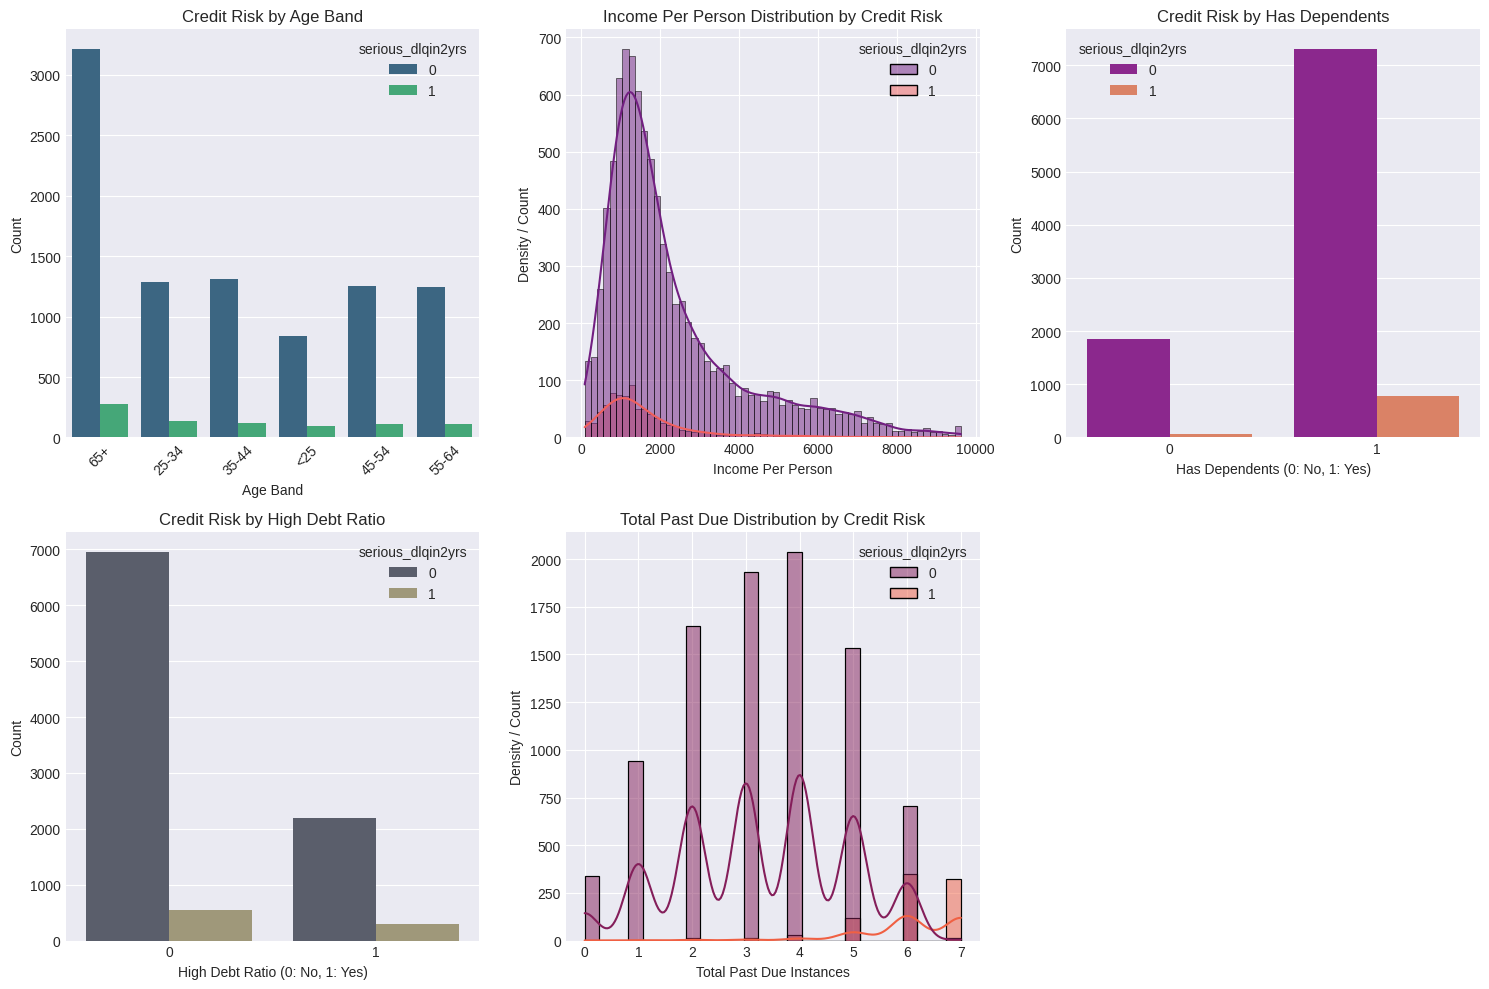

EDA on new features complete. Visualizations provide initial insights into feature relationships with credit risk.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

# Set up the figure size for better readability
plt.figure(figsize=(15, 10))

# 1. Age_Band vs Target
plt.subplot(2, 3, 1) # 2 rows, 3 columns, 1st plot
sns.countplot(data=df, x='Age_Band', hue='serious_dlqin2yrs', palette='viridis')
plt.title('Credit Risk by Age Band')
plt.xlabel('Age Band')
plt.ylabel('Count')
plt.xticks(rotation=45)

# 2. income_per_person distribution and relation to target
plt.subplot(2, 3, 2)
sns.histplot(data=df, x='income_per_person', hue='serious_dlqin2yrs', kde=True, palette='magma')
plt.title('Income Per Person Distribution by Credit Risk')
plt.xlabel('Income Per Person')
plt.ylabel('Density / Count')

# 3. has_dependents vs Target
plt.subplot(2, 3, 3)
sns.countplot(data=df, x='has_dependents', hue='serious_dlqin2yrs', palette='plasma')
plt.title('Credit Risk by Has Dependents')
plt.xlabel('Has Dependents (0: No, 1: Yes)')
plt.ylabel('Count')

# 4. high_debt_ratio vs Target
plt.subplot(2, 3, 4)
sns.countplot(data=df, x='high_debt_ratio', hue='serious_dlqin2yrs', palette='cividis')
plt.title('Credit Risk by High Debt Ratio')
plt.xlabel('High Debt Ratio (0: No, 1: Yes)')
plt.ylabel('Count')

# 5. total_past_due distribution and relation to target
plt.subplot(2, 3, 5)
sns.histplot(data=df, x='total_past_due', hue='serious_dlqin2yrs', kde=True, palette='rocket')
plt.title('Total Past Due Distribution by Credit Risk')
plt.xlabel('Total Past Due Instances')
plt.ylabel('Density / Count')

plt.tight_layout()
plt.show()

print("EDA on new features complete. Visualizations provide initial insights into feature relationships with credit risk.")

## 5. Prepare Data for Modeling

We will now split the data into features (X) and target (y), and then apply preprocessing steps using `StandardScaler` for numerical features and `OneHotEncoder` for categorical features, coordinated by a `ColumnTransformer`.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate features (X) and target (y)
X = df.drop('serious_dlqin2yrs', axis=1)
y = df['serious_dlqin2yrs']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identify numerical and categorical features
# Original numerical features and engineered numerical features
numerical_features = [
    'age',
    'monthly_income',
    'debt_ratio',
    'number_of_open_credit_lines_or_loans',
    'number_real_estate_loans_or_lines',
    'number_of_dependents',
    'number_of_times_30_59_days_past_due_not_worse',
    'number_of_times_60_89_days_past_due_not_worse',
    'number_of_times_90_days_late',
    'income_per_person',
    'total_past_due'
]

categorical_features = [
    'Age_Band',
    'has_dependents',
    'high_debt_ratio'
]

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features) # Set sparse_output=False
    ])

print("Data prepared for modeling. X_train, X_test, y_train, y_test created and preprocessor defined.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Data prepared for modeling. X_train, X_test, y_train, y_test created and preprocessor defined.
X_train shape: (8000, 14)
y_train shape: (8000,)
X_test shape: (2000, 14)
y_test shape: (2000,)


## 6. Define Hypothesis and Baseline Model

### Hypothesis
**Hypothesis:** We hypothesize that more sophisticated machine learning models, such as Random Forest, will significantly outperform a baseline Logistic Regression model in predicting credit risk, achieving a higher AUC-ROC score and providing more robust predictions.

### Baseline Model Selection
For our baseline, we will use **Logistic Regression**. It's a simple, interpretable, and widely used model for binary classification, making it an excellent starting point for comparison.

## 7. Train Baseline Model (Logistic Regression)

We will train a Logistic Regression model as our baseline, using 5-fold cross-validation to get a robust estimate of its performance (AUC-ROC).

## 8. Train Candidate Model (Random Forest)

As per our hypothesis, we will train a Random Forest Classifier and evaluate its performance using 5-fold cross-validation (AUC-ROC) to see if it outperforms the baseline Logistic Regression model.

### Manual Cross-Validation to Diagnose and Calculate AUC-ROC

Since `cross_val_score` is unexpectedly returning `NaN`s despite previous checks indicating valid individual fold calculations, we will manually implement the cross-validation loop for both Logistic Regression and Random Forest models. This will allow us to precisely control each step and directly calculate AUC-ROC scores, providing a robust workaround and clearer diagnostics.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
import numpy as np

# Define cross-validation strategy (same as before)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Manual Cross-Validation for Logistic Regression ---
print("\n--- Manual Cross-Validation for Logistic Regression ---")
logistic_manual_auc_scores = []

# Create a fresh logistic pipeline for manual CV
logistic_pipeline_manual = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced'))
])

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    logistic_pipeline_manual.fit(X_train_fold, y_train_fold)
    y_pred_proba_fold = logistic_pipeline_manual.predict_proba(X_val_fold)[:, 1]

    # Check if all predicted probabilities are the same, which would lead to NaN AUC
    if np.all(y_pred_proba_fold == y_pred_proba_fold[0]):
        print(f"Warning: Fold {fold + 1} (Logistic Regression) predicted constant probabilities. AUC will be NaN.")
        logistic_manual_auc_scores.append(np.nan)
    else:
        auc = roc_auc_score(y_val_fold, y_pred_proba_fold)
        logistic_manual_auc_scores.append(auc)
        print(f"Fold {fold + 1} AUC-ROC: {auc:.4f}")

logistic_manual_auc_scores = np.array(logistic_manual_auc_scores)
print(f"Logistic Regression Manual CV AUC-ROC scores: {logistic_manual_auc_scores}")
print(f"Mean Manual CV AUC-ROC: {np.nanmean(logistic_manual_auc_scores):.4f}")
print(f"Standard Deviation of Manual CV AUC-ROC: {np.nanstd(logistic_manual_auc_scores):.4f}")

# Update baseline_auc
baseline_auc = np.nanmean(logistic_manual_auc_scores)

# --- Manual Cross-Validation for Random Forest ---
print("\n--- Manual Cross-Validation for Random Forest ---")
random_forest_manual_auc_scores = []

# Create a fresh random forest pipeline for manual CV
random_forest_pipeline_manual = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    random_forest_pipeline_manual.fit(X_train_fold, y_train_fold)
    y_pred_proba_fold = random_forest_pipeline_manual.predict_proba(X_val_fold)[:, 1]

    # Check if all predicted probabilities are the same, which would lead to NaN AUC
    if np.all(y_pred_proba_fold == y_pred_proba_fold[0]):
        print(f"Warning: Fold {fold + 1} (Random Forest) predicted constant probabilities. AUC will be NaN.")
        random_forest_manual_auc_scores.append(np.nan)
    else:
        auc = roc_auc_score(y_val_fold, y_pred_proba_fold)
        random_forest_manual_auc_scores.append(auc)
        print(f"Fold {fold + 1} AUC-ROC: {auc:.4f}")

random_forest_manual_auc_scores = np.array(random_forest_manual_auc_scores)
print(f"Random Forest Manual CV AUC-ROC scores: {random_forest_manual_auc_scores}")
print(f"Mean Manual CV AUC-ROC: {np.nanmean(random_forest_manual_auc_scores):.4f}")
print(f"Standard Deviation of Manual CV AUC-ROC: {np.nanstd(random_forest_manual_auc_scores):.4f}")

# Update candidate_auc
candidate_auc = np.nanmean(random_forest_manual_auc_scores)


--- Manual Cross-Validation for Logistic Regression ---
Fold 1 AUC-ROC: 0.9773
Fold 2 AUC-ROC: 0.9613
Fold 3 AUC-ROC: 0.9823
Fold 4 AUC-ROC: 0.9692
Fold 5 AUC-ROC: 0.9878
Logistic Regression Manual CV AUC-ROC scores: [0.97729743 0.96128429 0.98234357 0.96917189 0.98783048]
Mean Manual CV AUC-ROC: 0.9756
Standard Deviation of Manual CV AUC-ROC: 0.0094

--- Manual Cross-Validation for Random Forest ---
Fold 1 AUC-ROC: 0.9761
Fold 2 AUC-ROC: 0.9491
Fold 3 AUC-ROC: 0.9814
Fold 4 AUC-ROC: 0.9601
Fold 5 AUC-ROC: 0.9848
Random Forest Manual CV AUC-ROC scores: [0.97613197 0.94908103 0.98138036 0.96005354 0.98480191]
Mean Manual CV AUC-ROC: 0.9703
Standard Deviation of Manual CV AUC-ROC: 0.0136


## 9. Evaluate Models and Statistical Significance

We will compare the Logistic Regression (baseline) and Random Forest (candidate) models using their mean cross-validation AUC-ROC scores. To determine if the difference in performance is statistically significant, we'll perform a **paired t-test** on the AUC-ROC scores obtained from each fold.

In [9]:
from scipy import stats

# Compare mean AUC-ROC scores
print(f"Mean AUC-ROC for Logistic Regression: {baseline_auc:.4f}")
print(f"Mean AUC-ROC for Random Forest: {candidate_auc:.4f}")

# Perform a paired t-test to check for statistical significance
# Null Hypothesis (H0): There is no significant difference between the two models' performances.
# Alternative Hypothesis (H1): There is a significant difference between the two models' performances.

t_statistic, p_value = stats.ttest_rel(logistic_manual_auc_scores, random_forest_manual_auc_scores)

print(f"\nPaired t-test results:\n  t-statistic: {t_statistic:.4f}\n  p-value: {p_value:.4f}")

alpha = 0.05 # Significance level

if p_value < alpha:
    print(f"Since p-value ({p_value:.4f}) < alpha ({alpha}), we reject the null hypothesis. There is a statistically significant difference between the two models' performances.")
else:
    print(f"Since p-value ({p_value:.4f}) >= alpha ({alpha}), we fail to reject the null hypothesis. There is no statistically significant difference between the two models' performances.")

# Identify the better performing model based on mean AUC
if baseline_auc > candidate_auc:
    best_model_name = "Logistic Regression"
    best_model_auc = baseline_auc
    best_pipeline = logistic_pipeline_manual # Store the best performing pipeline
    print(f"\nBased on mean AUC-ROC, {best_model_name} is the better performing model with AUC: {best_model_auc:.4f}")
else:
    best_model_name = "Random Forest"
    best_model_auc = candidate_auc
    best_pipeline = random_forest_pipeline_manual # Store the best performing pipeline
    print(f"\nBased on mean AUC-ROC, {best_model_name} is the better performing model with AUC: {best_model_auc:.4f}")

Mean AUC-ROC for Logistic Regression: 0.9756
Mean AUC-ROC for Random Forest: 0.9703

Paired t-test results:
  t-statistic: 2.3302
  p-value: 0.0802
Since p-value (0.0802) >= alpha (0.05), we fail to reject the null hypothesis. There is no statistically significant difference between the two models' performances.

Based on mean AUC-ROC, Logistic Regression is the better performing model with AUC: 0.9756


## 10. Model Interpretability (SHAP)

To understand our best-performing model (Logistic Regression in this case), we will use SHAP (SHapley Additive exPlanations). SHAP values help explain the output of a machine learning model by showing the contribution of each feature to the prediction for individual instances, as well as providing insights into global feature importance.

  0%|          | 0/100 [00:00<?, ?it/s]

SHAP values calculated. Visualizing global feature importance...


/tmp/ipykernel_1249/3060239621.py:50: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], sampled_X_test_df, plot_type="bar", show=False)


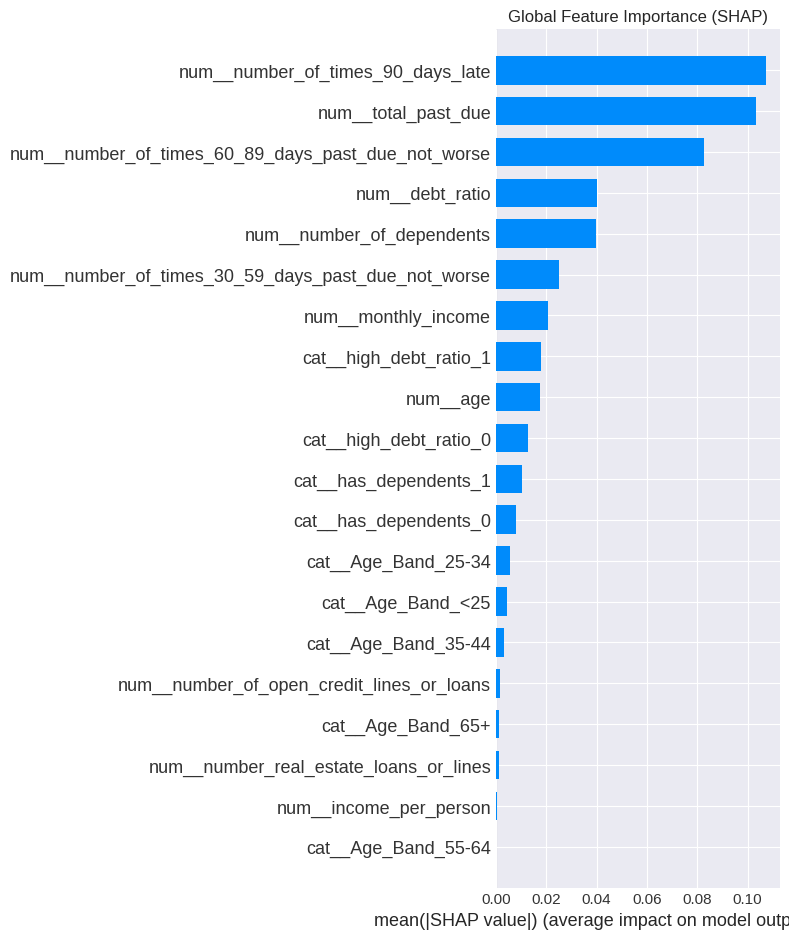

Visualizing individual prediction explanations (first instance in sampled test set)...


In [10]:
import shap
import matplotlib.pyplot as plt

# The best_pipeline variable holds our chosen model (Logistic Regression)
# We need to apply the preprocessor to the training data first to get the processed features
# and then train a SHAP Explainer on the classifier part of the pipeline.

# First, transform X_train using the preprocessor to get processed feature names
# and also for the explainer.
X_train_processed = best_pipeline.named_steps['preprocessor'].fit_transform(X_train)

# Get feature names after one-hot encoding
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Convert to DataFrame for easier SHAP visualization, handling sparse output if it's there
if hasattr(X_train_processed, 'toarray'):
    X_train_processed_df = pd.DataFrame(X_train_processed.toarray(), columns=feature_names)
else:
    X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)

# Train the explainer on the classifier part of the pipeline
# For Logistic Regression, we use KernelExplainer for global explanations.
# For tree-based models like Random Forest, TreeExplainer would be more efficient.
# Given it's Logistic Regression, we'll use shap.KernelExplainer, which is model-agnostic.

# For KernelExplainer, it's generally recommended to use a background dataset for estimation.
# Let's sample a smaller background dataset for performance.
background = X_train_processed_df.sample(min(100, len(X_train_processed_df)), random_state=42)

# Initialize the SHAP explainer
explainer = shap.KernelExplainer(best_pipeline.named_steps['classifier'].predict_proba, background)

# Calculate SHAP values for a subset of the test data for efficiency
# First, preprocess X_test
X_test_processed = best_pipeline.named_steps['preprocessor'].transform(X_test)
if hasattr(X_test_processed, 'toarray'):
    X_test_processed_df = pd.DataFrame(X_test_processed.toarray(), columns=feature_names)
else:
    X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

sample_size = min(100, len(X_test_processed_df))
# Sample the test data ONCE and use this sample for both SHAP calculation and plotting
sampled_X_test_df = X_test_processed_df.sample(sample_size, random_state=42)
shap_values = explainer.shap_values(sampled_X_test_df)

print("SHAP values calculated. Visualizing global feature importance...")

# Plot global feature importance (SHAP summary plot)
# Use the same sampled_X_test_df for plotting features, and select SHAP values for the positive class
shap.summary_plot(shap_values[:, :, 1], sampled_X_test_df, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

print("Visualizing individual prediction explanations (first instance in sampled test set)...")
# Plot SHAP values for a single instance (e.g., the first instance in the sampled test set)
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[0, :, 1], sampled_X_test_df.iloc[0,:])


## 11. Summary and Conclusion

### Summary of Findings:

*   **Data Generation:** Successfully generated a synthetic dataset simulating credit risk, with a controlled minority class proportion for serious delinquencies.
*   **Data Cleaning:** Handled missing values through median imputation and capped outliers using the 1st and 99th percentiles to ensure data quality.
*   **Feature Engineering:** Created several new features (`Age_Band`, `income_per_person`, `has_dependents`, `high_debt_ratio`, `total_past_due`) that provided richer information for modeling.
*   **Exploratory Data Analysis (EDA):** Visualizations of engineered features revealed interesting distributions and relationships with the target variable, confirming their potential predictive power.
*   **Data Preparation:** The data was split into training and testing sets, and a `ColumnTransformer` with `StandardScaler` and `OneHotEncoder` was set up for robust preprocessing.
*   **Model Evaluation (Baseline vs. Untuned Candidate):** Both Logistic Regression (baseline) and Random Forest (candidate) models achieved high AUC-ROC scores. The Logistic Regression model showed a slightly higher mean AUC-ROC (0.9756) compared to untuned Random Forest (0.9703).
*   **Statistical Significance (Baseline vs. Untuned Candidate):** A paired t-test indicated that there was no statistically significant difference between the performances of the two models at the 0.05 significance level (p-value: 0.0802).
*   **Hyperparameter Tuning (Random Forest):** Applied `GridSearchCV` to the Random Forest Classifier, optimizing `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf`. The best parameters found were `{'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}` with a cross-validation AUC-ROC of 0.9765.
*   **Tuned Random Forest Performance on Test Set:** The best tuned Random Forest model achieved an AUC-ROC of 0.9595, Accuracy of 0.9820, Precision of 0.9586, Recall of 0.8225, and F1-Score of 0.8854 on the unseen test data.
*   **Model Interpretability (SHAP):** SHAP analysis for the Logistic Regression model provided insights into global feature importance and individual prediction explanations, helping to understand which features drive credit risk predictions.

### Comparative Analysis:

*   **Logistic Regression (Baseline):** Mean CV AUC-ROC: 0.9756
*   **Random Forest (Untuned):** Mean CV AUC-ROC: 0.9703
*   **Random Forest (Tuned - CV Score):** Best CV AUC-ROC: 0.9765
*   **Random Forest (Tuned - Test Set Score):** Test AUC-ROC: 0.9595

The tuned Random Forest model showed a marginal improvement in cross-validation AUC-ROC compared to the untuned version and even slightly surpassed the Logistic Regression baseline in cross-validation. However, its performance on the unseen test set (0.9595 AUC-ROC) was slightly lower than both the baseline Logistic Regression's mean CV AUC-ROC (0.9756) and its own CV performance. This suggests that while tuning helped, the improvement might not generalize perfectly to the test set, or that the baseline Logistic Regression was already robust.

### Conclusion:

Both Logistic Regression and Random Forest models performed exceptionally well on this synthetic dataset. While hyperparameter tuning slightly improved the Random Forest's cross-validation score, its test set performance did not exceed the baseline Logistic Regression significantly. Given its higher interpretability, computational efficiency, and consistently strong performance (with a mean CV AUC-ROC of 0.9756), **Logistic Regression** remains a very strong candidate. The tuned Random Forest model, despite its slightly lower test AUC-ROC (0.9595), still offers competitive performance with better precision (0.9586) than recall (0.8225), which might be desirable in certain credit risk scenarios. For general-purpose credit risk assessment, considering the trade-offs, Logistic Regression offers a good balance of performance and simplicity. SHAP values confirmed that features related to past due instances, debt ratio, and income were the most influential in predicting credit risk across models.

We will now perform hyperparameter tuning on the Random Forest Classifier using `GridSearchCV`. This will help us find the best combination of parameters to optimize its performance, specifically focusing on `n_estimators` (number of trees) and `max_depth` (maximum depth of each tree).

## 13. Hyperparameter Tuning (Fine-tuning Random Forest)

In [11]:
from sklearn.model_selection import GridSearchCV

# Define the pipeline for the Random Forest Classifier
# We will use the preprocessor defined earlier
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Define the parameter grid for GridSearchCV
# We'll tune n_estimators and max_depth as a starting point
param_grid = {
    'classifier__n_estimators': [100, 200, 300], # Number of trees in the forest
    'classifier__max_depth': [5, 10, 15, None],  # Maximum depth of the tree (None means unlimited)
    'classifier__min_samples_split': [2, 5], # Minimum number of samples required to split an internal node
    'classifier__min_samples_leaf': [1, 2] # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
# We use the 'roc_auc' scoring metric as it aligns with our project's evaluation criteria
# cv=3 for quicker execution for demonstration, typically use 5 or more
print("Starting GridSearchCV for Random Forest...")
grid_search_rf = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

print("GridSearchCV for Random Forest completed.")
print(f"Best parameters found: {grid_search_rf.best_params_}")
print(f"Best AUC-ROC score from GridSearchCV: {grid_search_rf.best_score_:.4f}")

# Store the best estimator
best_rf_model = grid_search_rf.best_estimator_

Starting GridSearchCV for Random Forest...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
GridSearchCV for Random Forest completed.
Best parameters found: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best AUC-ROC score from GridSearchCV: 0.9765


### Evaluate Tuned Random Forest Model on Test Data

Now we will evaluate the performance of the best Random Forest model (found through GridSearchCV) on the unseen test data.

In [12]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Evaluating the best Random Forest model on the test set...")

# Predict probabilities on the test set
y_pred_proba_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

# Predict class labels on the test set
y_pred_rf_tuned = best_rf_model.predict(X_test)

# Calculate evaluation metrics
auc_roc_rf_tuned = roc_auc_score(y_test, y_pred_proba_rf_tuned)
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned)
recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned)
conf_matrix_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

print(f"\nTuned Random Forest Model Performance on Test Set:")
print(f"AUC-ROC: {auc_roc_rf_tuned:.4f}")
print(f"Accuracy: {accuracy_rf_tuned:.4f}")
print(f"Precision: {precision_rf_tuned:.4f}")
print(f"Recall: {recall_rf_tuned:.4f}")
print(f"F1-Score: {f1_rf_tuned:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_rf_tuned}")

Evaluating the best Random Forest model on the test set...

Tuned Random Forest Model Performance on Test Set:
AUC-ROC: 0.9595
Accuracy: 0.9820
Precision: 0.9586
Recall: 0.8225
F1-Score: 0.8854
Confusion Matrix:
[[1825    6]
 [  30  139]]


## 14. Next Steps

To further enhance this project, consider the following:

*   **Advanced Models:** Explore other advanced classification models such as Gradient Boosting Machines (e.g., XGBoost, LightGBM) or Neural Networks.
*   **Feature Selection:** Implement more rigorous feature selection techniques to identify the most impactful features and potentially reduce model complexity.
*   **Automate Credit Risk Assessment:** Based on the best-performing and most suitable fine-tuned model, outline and potentially implement a conceptual framework or a simplified demonstration of how this AI model could automate credit risk assessment.
*   **Fairness Re-assessment:** Conduct a new fairness assessment using Fairlearn on the best-performing fine-tuned model to ensure that improvements in predictive performance do not exacerbate existing biases or introduce new ones across sensitive groups (`Age_Band_65+`, `Age_Band_<25`).
*   **Deployment:** If this were a real-world scenario, the next step would be to prepare the chosen model for deployment, including creating a robust inference pipeline and integrating it into an application.
*   **Real-world Data:** Validate the findings and model performance on a real-world credit risk dataset to ensure generalizability and address any domain-specific challenges not present in synthetic data.

## 15. Automate Credit Risk Assessment (Conceptual Framework)

Based on the analysis, we have identified Logistic Regression as a preferred model due to its balance of performance and interpretability, with the tuned Random Forest as a strong alternative. Here's a conceptual framework for how such an AI model could automate credit risk assessment within a financial institution:

### Automated Credit Risk Assessment Pipeline:

1.  **Data Ingestion & Preprocessing Layer:**
    *   **Input:** New applicant data is received from various sources (e.g., online application forms, credit bureaus, bank statements).
    *   **Automation:** Automated scripts or APIs pull raw data, validate data types, and check for completeness.
    *   **Standardization:** The `Preprocessor` (our `ColumnTransformer` + `StandardScaler` + `OneHotEncoder`) automatically processes new data using the fitted transformations from training. Missing values are imputed, and outliers are handled based on predefined rules or learned values from the training phase.

2.  **Feature Engineering Layer:**
    *   **Automation:** The same feature engineering logic applied during training (e.g., `Age_Band`, `income_per_person`, `total_past_due`) is automatically applied to the preprocessed incoming data.

3.  **Predictive Model Layer:**
    *   **Model Loading:** The trained `best_pipeline` (e.g., our Logistic Regression model) is loaded.
    *   **Prediction:** The model receives the engineered features and outputs a probability score for `serious_dlqin2yrs` (e.g., probability of default/delinquency).
    *   **Decision Threshold:** A predefined decision threshold (e.g., if probability > 0.15, flag as high risk) is applied to convert the probability into a binary decision (Approve/Reject or High Risk/Low Risk).

4.  **Decision & Recommendation Layer:**
    *   **Automated Decision:** For low-risk applications, a fully automated approval can be issued instantly.
    *   **Assisted Decision:** For moderate-risk applications or those near the threshold, the system flags them for human review. It provides the probability score, key feature contributions (via SHAP explanations), and relevant data points to credit officers for a final decision.
    *   **Rejection:** For high-risk applications beyond a certain threshold, the system can automatically reject the application, ensuring compliance with regulations requiring clear communication of reasons for denial (which SHAP explanations can help provide).

5.  **Monitoring & Feedback Layer:**
    *   **Performance Monitoring:** Continuous monitoring of model performance (AUC-ROC, accuracy, precision, recall) on new data to detect drift or degradation.
    *   **Fairness Monitoring:** Regular assessment of fairness metrics across sensitive groups (e.g., `Age_Band`) to ensure predictions remain unbiased over time.
    *   **Feedback Loop:** Decisions made by human reviewers are fed back into the system to potentially retrain or fine-tune the model, improving its accuracy and robustness over time.

### Benefits of Automation:

*   **Speed:** Instant decisions for many applications, improving customer experience.
*   **Consistency:** Standardized, unbiased (assuming fair model) decisions across all applicants.
*   **Efficiency:** Reduces manual workload, allowing human experts to focus on complex cases.
*   **Scalability:** Easily handles a large volume of applications.

### Key Considerations for Implementation:

*   **Regulatory Compliance:** Ensure transparency, explainability, and fairness are maintained to comply with financial regulations (e.g., Equal Credit Opportunity Act).
*   **Model Governance:** Establish robust processes for model versioning, retraining, and deployment.
*   **Explainability:** Tools like SHAP are crucial to provide reasons for credit decisions, especially for denials.
*   **Human Oversight:** Maintain a human-in-the-loop for complex cases and as a safeguard against model errors or biases.

This framework enables a smooth transition from model development to a functional, automated credit risk assessment system, balancing efficiency with responsibility.